# Análisis Exploratorio de Datos: Panel Histórico Reconstruido
Este notebook tiene como objetivo explorar el dataset `panel_historico_reconstruido.csv` para identificar posibles errores o inconsistencias en la forma en que se modelaron y reconstruyeron las interacciones antes de usarlo para entrenar un modelo.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')


C:\Users\juansoag\AppData\Local\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\juansoag\AppData\Local\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


In [2]:
# Cargar el dataset reconstruido
df = pd.read_csv('panel_historico_reconstruido.csv')
print(f"Dimensiones del dataset: {df.shape}")
display(df.head())


Dimensiones del dataset: (5776, 340)


,id_candidato,red_social,fecha,hora,usuario,texto,url,platform,t0_individual,total_interacciones,...,fb_angry_nuevas_d5,fb_angry_nuevas_d6,fb_angry_nuevas_d7,fb_angry_nuevas_d8,fb_angry_nuevas_d9,fb_angry_nuevas_d10,fb_angry_nuevas_d11,fb_angry_nuevas_d12,fb_angry_nuevas_d13,fb_angry_nuevas_d14
0,COL-05001-010,Facebook,2023-10-28,17:20:31,albertyordanocorredor,La plena inclusión en Medellín es un compromis...,https://www.facebook.com/albertyordanocorredor...,Facebook,2.182300,513,...,0,0,0,0,0,0,0,0,0,0
1,COL-05001-010,Facebook,2023-10-28,16:05:24,albertyordanocorredor,Esto fue lo qué pasó con la broma que le hicim...,https://www.facebook.com/soykike89/videos/2460...,Facebook,2.223967,1843,...,0,0,0,0,0,0,0,0,0,0
2,COL-05001-010,Facebook,2023-10-28,14:56:44,albertyordanocorredor,Aquí hay una alternativa distinta a Fico y a Q...,https://www.facebook.com/albertyordanocorredor...,Facebook,2.307300,496,...,0,0,0,0,0,0,0,0,0,0
3,COL-05001-010,Facebook,2023-10-28,14:03:34,albertyordanocorredor,"Aquí no hay solamente equipo de trabajo, aquí ...",https://www.facebook.com/reel/889427628897103/,Facebook,2.307300,457,...,0,0,0,0,0,0,0,0,0,0
4,COL-05001-010,Facebook,2023-10-28,12:00:47,albertyordanocorredor,Cuando mis hijos preguntan por qué estamos tra...,https://www.facebook.com/albertyordanocorredor...,Facebook,2.390633,539,...,0,0,0,0,0,0,0,0,0,0


## 1. Verificación de Monotonía y Valores Negativos
Las interacciones acumuladas deben ser siempre crecientes (o constantes) y las interacciones nuevas por día no deben ser negativas. Esto es fundamental para confirmar que la curva de Weibull se aplicó correctamente.


In [3]:
# Identificar las columnas de 'nuevas'
nuevas_cols = [c for c in df.columns if '_nuevas_d' in c]

# Comprobar si hay valores negativos
negativos = (df[nuevas_cols] < 0).sum().sum()
print(f"Total de valores negativos en interacciones nuevas: {negativos}")

if negativos > 0:
    print("¡Alerta! Existen valores negativos en las interacciones diarias nuevas, lo cual indica un error en el modelo de reconstrucción.")
else:
    print("✓ Las interacciones diarias nuevas son todas mayores o iguales a cero.")


Total de valores negativos en interacciones nuevas: 0
✓ Las interacciones diarias nuevas son todas mayores o iguales a cero.


## 2. Consistencia entre Acumuladas y Nuevas
La suma de las interacciones nuevas desde el día 0 hasta el día 14 debe ser igual a la interacción acumulada en el día 14.


In [4]:
tipos_interaccion = ['likes', 'comentarios', 'compartidos', 'vistas', 'favoritos', 'fb_love', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']

errores_consistencia = 0
tipos_analizados = []

for tipo in tipos_interaccion:
    col_final = f'{tipo}_acum_d14'
    if col_final in df.columns:
        tipos_analizados.append(tipo)
        cols_nuevas = [f'{tipo}_nuevas_d{i}' for i in range(15)]
        
        suma_nuevas = df[cols_nuevas].sum(axis=1)
        acum_final = df[col_final]
        
        # Verificar si hay discrepancias (margen por redondeo flotante)
        discrepancias = np.abs(suma_nuevas - acum_final) > 1
        if discrepancias.sum() > 0:
            print(f"¡Alerta! Hay {discrepancias.sum()} publicaciones con inconsistencias en '{tipo}'.")
            errores_consistencia += discrepancias.sum()

print(f"Tipos de interacción analizados: {tipos_analizados}")
if errores_consistencia == 0:
    print("✓ Todas las sumas de interacciones nuevas coinciden con sus respectivos acumulados finales.")


Tipos de interacción analizados: ['likes', 'comentarios', 'compartidos', 'vistas', 'favoritos', 'fb_love', 'fb_haha', 'fb_care', 'fb_wow', 'fb_sad', 'fb_angry']
✓ Todas las sumas de interacciones nuevas coinciden con sus respectivos acumulados finales.


## 3. Visualización de Curvas de Crecimiento
Vamos a visualizar cómo crecen las interacciones acumuladas para una muestra aleatoria de publicaciones en cada plataforma. Esto nos permite ver si la forma de las curvas de Weibull tiene sentido.


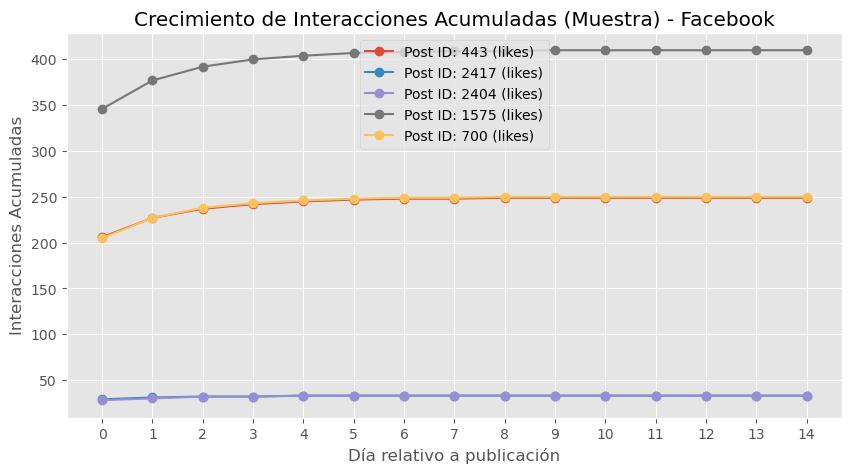

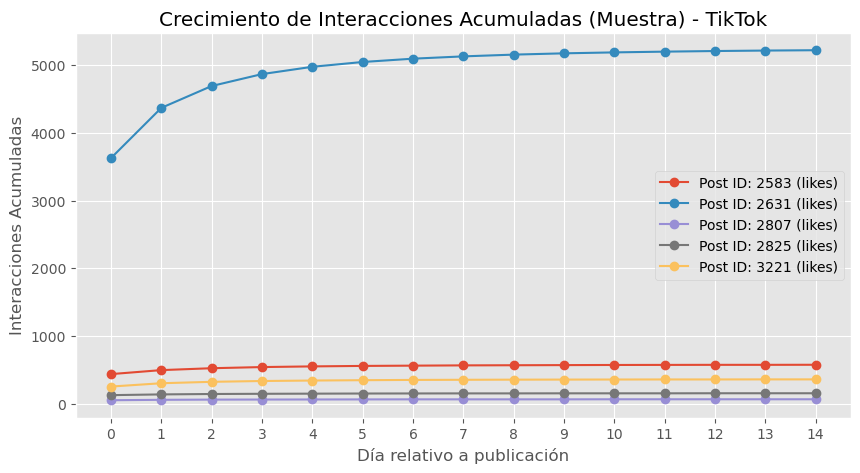

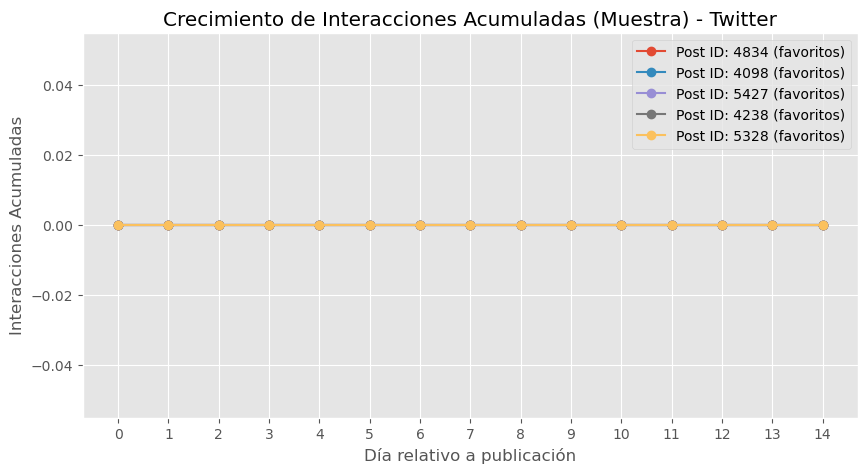

In [5]:
dias = list(range(15))

for plat in df['platform'].unique():
    df_plat = df[df['platform'] == plat]
    if len(df_plat) == 0:
        continue
        
    # Seleccionar hasta 5 publicaciones al azar
    muestra = df_plat.sample(n=min(5, len(df_plat)), random_state=42)
    
    plt.figure(figsize=(10, 5))
    has_plot = False
    for idx, row in muestra.iterrows():
        # Priorizar una métrica válida según la plataforma
        metrica = 'likes' if f'likes_acum_d0' in df.columns and not pd.isna(row.get('likes_acum_d14', np.nan)) else None
        if plat == 'Twitter' and 'favoritos_acum_d0' in df.columns:
            metrica = 'favoritos'
            
        if metrica and f'{metrica}_acum_d0' in row:
            valores = [row.get(f'{metrica}_acum_d{d}', 0) for d in dias]
            plt.plot(dias, valores, marker='o', label=f"Post ID: {idx} ({metrica})")
            has_plot = True
            
    if has_plot:
        plt.title(f'Crecimiento de Interacciones Acumuladas (Muestra) - {plat}')
        plt.xlabel('Día relativo a publicación')
        plt.ylabel('Interacciones Acumuladas')
        plt.xticks(dias)
        plt.legend()
        plt.show()
    else:
        plt.close()


## 4. Distribución del t0_individual

A primera vista, podría parecer un error que los valores de Facebook sean mayores a 2. Sin embargo, no lo es. El `t0_individual` se calcula sumando dos factores independientes:
$$t0_{individual} = t0_{base} + t0_{hora}$$
* **$t0_{hora}$**: Es la fracción del día que queda hasta las 23:00 (que va de 0 a 1).
* **$t0_{base}$**: Es el parámetro estructural de la plataforma, que viene calibrado de `weibull_params.csv` (Costa Rica). Para Facebook es `1.9323`, para Twitter es `0.2566`.

Esto desplaza la distribución de Facebook, reflejando matemáticamente que su curva de saturación es más prolongada en el tiempo comparada con otras redes. A continuación se muestra su distribución:


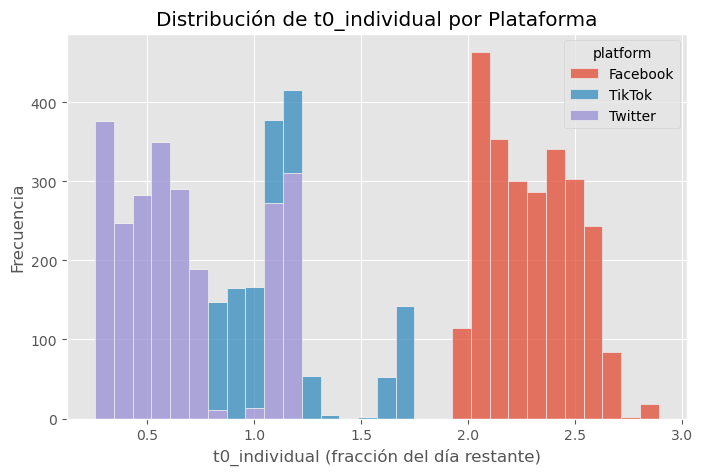

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='t0_individual', hue='platform', multiple='stack', bins=30)
plt.title('Distribución de t0_individual por Plataforma')
plt.xlabel('t0_individual (fracción del día restante)')
plt.ylabel('Frecuencia')
plt.show()


## 5. Análisis del Total de Interacciones y Correlaciones
Verificar que la variable `total_interacciones` sea consistente. Los picos masivos o valores extremos (outliers) se pueden ver a continuación.


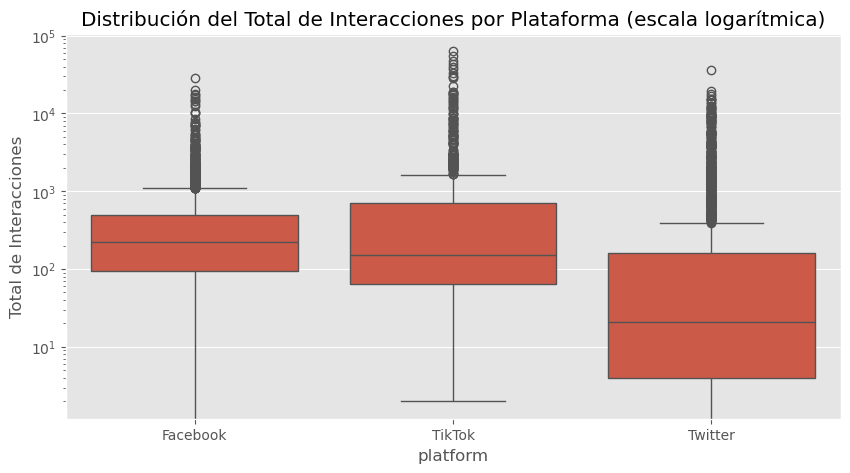

In [7]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df, x='platform', y='total_interacciones')
plt.yscale('log')
plt.title('Distribución del Total de Interacciones por Plataforma (escala logarítmica)')
plt.ylabel('Total de Interacciones')
plt.show()


## 6. Pruebas de Respaldo Estadístico (Statistical Backing)

Para complementar el análisis visual y tener un respaldo estadístico más sólido, realizaremos dos pruebas formales:

1. **Prueba H de Kruskal-Wallis**: Evalúa si la mediana del total de interacciones difiere significativamente entre las plataformas. (Usamos pruebas no paramétricas debido a la distribución fuertemente asimétrica y a la presencia natural de outliers).
2. **Correlación de Spearman**: Evalúa si existe una relación monótona fuerte entre el número de likes y el número de comentarios (usando Facebook como ejemplo), lo que valida que las métricas crecen en proporciones coherentes.


In [8]:
from scipy import stats

print("=== PRUEBAS DE RESPALDO ESTADÍSTICO ===\n")

# 1. Kruskal-Wallis para total de interacciones por plataforma
grupos = [df[df['platform'] == plat]['total_interacciones'].dropna() for plat in df['platform'].unique()]
stat, p_val = stats.kruskal(*grupos)
print("1. Prueba H de Kruskal-Wallis (Diferencia de medianas entre plataformas)")
print(f"   Estadístico H: {stat:.2f}, p-valor: {p_val:.2e}")
if p_val < 0.05:
    print("   Conclusión: Las medianas de las interacciones totales difieren significativamente entre plataformas.")
    print("   (Es estadísticamente correcto tratar a las plataformas con pesos o escalas distintas).\n")
else:
    print("   Conclusión: No hay evidencia de diferencia significativa entre plataformas.\n")

# 2. Correlación de Spearman entre métricas
print("2. Correlación de Spearman (Consistencia interna de métricas para Facebook)")
df_fb = df[df['platform'] == 'Facebook']

if 'likes_acum_d14' in df_fb.columns and 'comentarios_acum_d14' in df_fb.columns:
    corr, p_val_corr = stats.spearmanr(df_fb['likes_acum_d14'], df_fb['comentarios_acum_d14'])
    print(f"   Correlación Likes vs Comentarios: {corr:.3f}, p-valor: {p_val_corr:.2e}")
    if p_val_corr < 0.05 and corr > 0:
        print("   Conclusión: Existe una correlación monótona positiva muy significativa. Las publicaciones que reciben más likes también reciben más comentarios proporcionalmente.")
else:
    print("   No se encontraron las columnas 'likes_acum_d14' y 'comentarios_acum_d14' para hacer la prueba.")


=== PRUEBAS DE RESPALDO ESTADÍSTICO ===

1. Prueba H de Kruskal-Wallis (Diferencia de medianas entre plataformas)
   Estadístico H: 1109.23, p-valor: 1.36e-241
   Conclusión: Las medianas de las interacciones totales difieren significativamente entre plataformas.
   (Es estadísticamente correcto tratar a las plataformas con pesos o escalas distintas).

2. Correlación de Spearman (Consistencia interna de métricas para Facebook)
   Correlación Likes vs Comentarios: 0.836, p-valor: 0.00e+00
   Conclusión: Existe una correlación monótona positiva muy significativa. Las publicaciones que reciben más likes también reciben más comentarios proporcionalmente.
